### Notebook: 01_LSA_20NG.ipynb — Clean LSA on 20 Newsgroups
**Data:** `topic_modeling/data/20newsgroups.csv`  
**Pipeline:** Clean (stopwords+contractions) → TF-IDF(1–2g) → TruncatedSVD → topics/wordclouds → metrics → export topics.


In [1]:
# ------------------------------------------------------------
# Cell 0 — Environment & folders
# ------------------------------------------------------------
import sys, platform
from pathlib import Path

print("Python exe :", sys.executable)
print("Python ver :", platform.python_version())

ROOT     = Path(r"C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling")
DATA_DIR = ROOT / "data"
FIG_DIR  = ROOT / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Folders ready:", DATA_DIR, "|", FIG_DIR)


Python exe : c:\Users\murth\Desktop\nlpSession02\codeBase\.venv\Scripts\python.exe
Python ver : 3.10.11
Folders ready: C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\data | C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\figures


### Cell 1 — Load CSV (reproducible)
Loads your saved 20NG CSV so all models see the **same corpus**.


In [2]:
# ------------------------------------------------------------
# Cell 1 — Load CSV
# ------------------------------------------------------------
import numpy as np, pandas as pd
from pathlib import Path

csv_path = Path(r"C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\data\20newsgroups.csv")
assert csv_path.exists(), f"Missing: {csv_path}"

df = pd.read_csv(csv_path)
docs_raw = df["text"].astype(str).tolist()
targets  = df["target"].to_numpy()
print(f"Docs: {len(docs_raw)} | Unique labels: {len(set(targets))}")


Docs: 6000 | Unique labels: 20


### Cell 2 — Clean (stopwords+contractions) + TF-IDF (1–2 grams)
Uses `utils_text.clean_corpus_to_strings` (stopwords removed, contractions expanded).  
Then TF-IDF with (1,2)-grams; we do **not** apply stop_words in the vectorizer (already cleaned).


In [3]:
# ------------------------------------------------------------
# Cell 2 — Clean + TF-IDF
# ------------------------------------------------------------
import sys
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

PROJECT_ROOT = Path(r"C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from utils_text import clean_corpus_to_strings

docs = clean_corpus_to_strings(docs_raw)  # stopwords & contractions handled

tfidf = TfidfVectorizer(
    max_df=0.6,
    min_df=10,
    ngram_range=(1,2),     # 1–2 grams
    stop_words=None        # already cleaned
)
X = tfidf.fit_transform(docs)
vocab = np.array(tfidf.get_feature_names_out())
print("TF-IDF:", X.shape, "| Vocab:", len(vocab))


TF-IDF: (6000, 7085) | Vocab: 7085


### Cell 3 — Fit LSA (TruncatedSVD), inspect top terms, wordclouds



Topic 00: nan, 32, os, bit, mac, scsi, ibm, 32 bit, pc, 92, 16, 93

Topic 01: does, know, people, think, did, god, good, time, new, make, way, want

Topic 02: god, people, jesus, believe, did, think, say, bible, christian, christians, christ, right

Topic 03: god, windows, jesus, does, bible, dos, file, believe, christian, christians, christ, know

Topic 04: drive, god, scsi, game, hard, ide, disk, drives, card, controller, hard drive, games

Topic 05: drive, scsi, government, key, chip, disk, people, hard, ide, drives, clipper, encryption

Topic 06: does, know, does know, car, card, did, anybody, surrender, shameful surrender, cadre dsl, cadre, pitt shameful

Topic 07: windows, dos, people, file, did, mouse, drive, problem, think, files, driver, run

Topic 08: shameful surrender, dsl, cadre, surrender soon, geb cadre, geb, dsl pitt, intellect geb, cadre dsl, pitt shameful, banks n3jxp, chastity

Topic 09: car, windows, bike, new, miles, 00, cars, engine, armenian, good, space, armeni

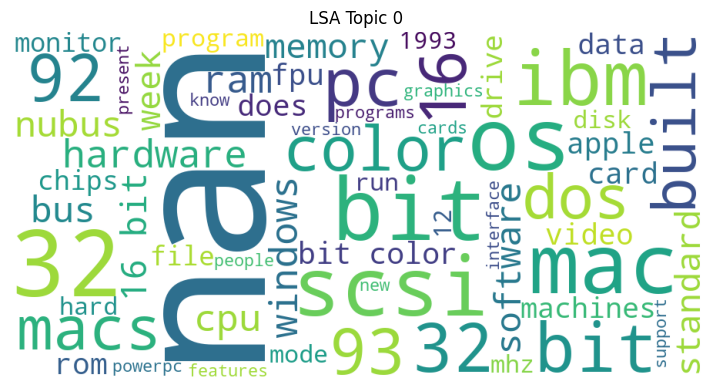

Saved C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\figures\lsa_topic_00_wordcloud.png


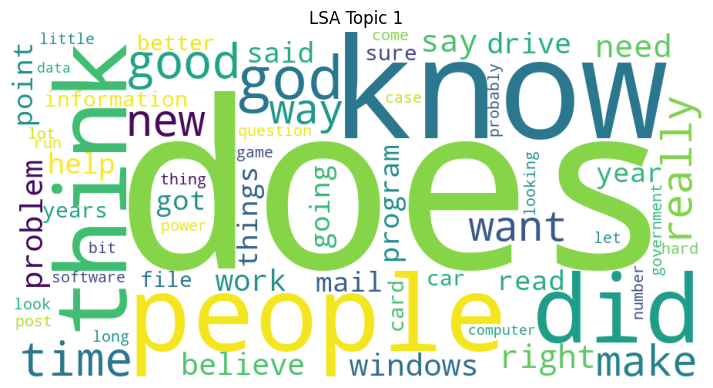

Saved C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\figures\lsa_topic_01_wordcloud.png


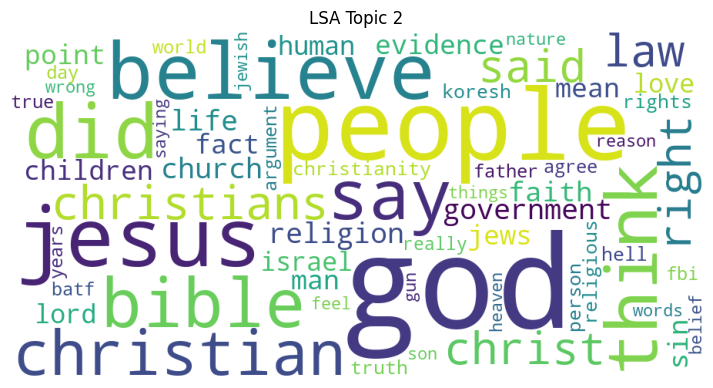

Saved C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\figures\lsa_topic_02_wordcloud.png


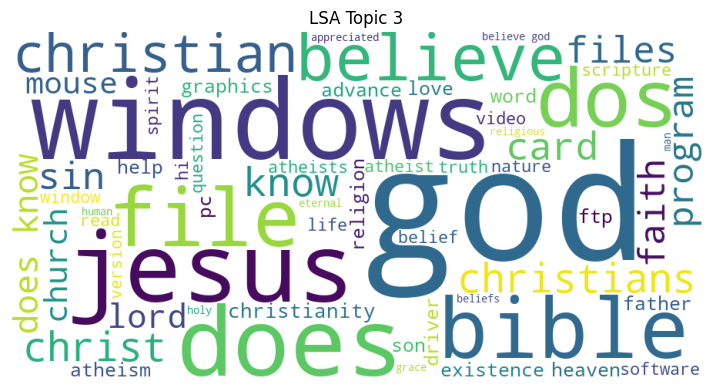

Saved C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\figures\lsa_topic_03_wordcloud.png


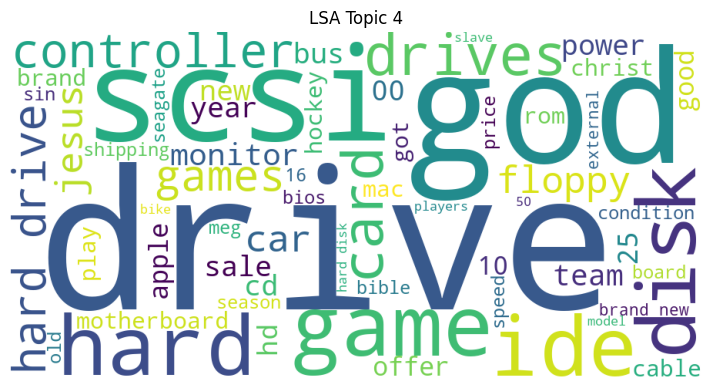

Saved C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\figures\lsa_topic_04_wordcloud.png


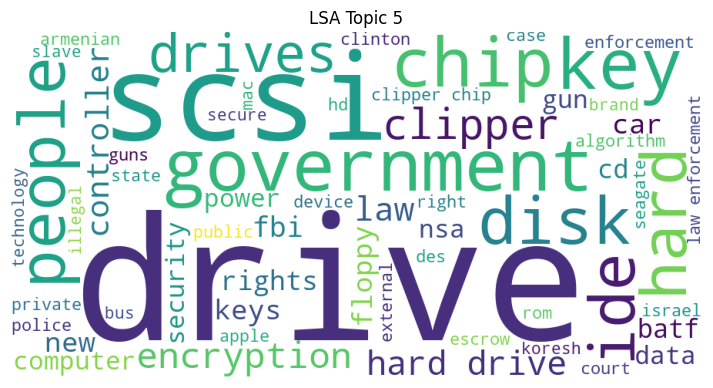

Saved C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\figures\lsa_topic_05_wordcloud.png


In [4]:
# ------------------------------------------------------------
# Cell 3 — LSA fit + topic inspection + wordclouds
# ------------------------------------------------------------
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from wordcloud import WordCloud

n_topics = 20
svd = TruncatedSVD(n_components=n_topics, random_state=42)
lsa = make_pipeline(svd, Normalizer(copy=False))
X_lsa = lsa.fit_transform(X)
components = svd.components_

def top_terms_for_topic(row, vocab, k=15):
    idx = np.argsort(row)[::-1][:k]
    return vocab[idx], row[idx]

# print top terms
for t in range(n_topics):
    terms, _ = top_terms_for_topic(components[t], vocab, k=12)
    print(f"\nTopic {t:02d}: {', '.join(terms)}")

# wordclouds
for t in range(min(6, n_topics)):
    terms, weights = top_terms_for_topic(components[t], vocab, k=60)
    wc = WordCloud(width=900, height=450, background_color="white")\
         .generate_from_frequencies({terms[i]: float(abs(weights[i])) for i in range(len(terms))})
    plt.figure(figsize=(9,4.5)); plt.imshow(wc); plt.axis("off"); plt.title(f"LSA Topic {t}")
    out = FIG_DIR / f"lsa_topic_{t:02d}_wordcloud.png"; plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print("Saved", out)


### Cell 4 — Metrics: Topic Diversity + Coherence (c_v) → append


In [5]:
# ------------------------------------------------------------
# Cell 4 — Diversity + Coherence (c_v)
# ------------------------------------------------------------
import numpy as np, pandas as pd
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

topn = 10
def top_words(row,k=topn): return np.array([w for w in vocab[np.argsort(row)[::-1][:k]]]).tolist()
topic_words = [top_words(components[t], topn) for t in range(components.shape[0])]

# diversity
all_top = [w for tw in topic_words for w in tw]
diversity = len(set(all_top))/(len(topic_words)*topn)
print(f"Topic Diversity (top {topn}): {diversity:.3f}")

# coherence on tokenized docs (split is safe; cleaner already removed stopwords)
tokenized = [d.split() for d in docs]
dictionary = Dictionary(tokenized)
corpus = [dictionary.doc2bow(toks) for toks in tokenized]
coh = CoherenceModel(topics=topic_words, texts=tokenized, dictionary=dictionary, coherence="c_v").get_coherence()
print(f"Coherence c_v: {coh:.3f}")

# append
cmp = DATA_DIR/"model_comparison.csv"
row = pd.DataFrame([{"model":"LSA","n_topics":len(topic_words),"topn":topn,"topic_diversity":diversity,"coherence_c_v":coh}])
row.to_csv(cmp, mode="a" if cmp.exists() else "w", header=not cmp.exists(), index=False)
print("Wrote ->", cmp)


Topic Diversity (top 10): 0.465
Coherence c_v: 0.451
Wrote -> C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\data\model_comparison.csv


### Cell 5 — Export LSA topics (top terms + exemplar doc) to CSV


In [6]:
# ------------------------------------------------------------
# Cell 5 — Export LSA topics
# ------------------------------------------------------------
import numpy as np, pandas as pd

def top_terms_list(row, k=10):
    idx = np.argsort(row)[::-1][:k]
    return vocab[idx].tolist()

doc_main = np.argmax(X_lsa, axis=1)
rows = []
for t in range(components.shape[0]):
    terms = top_terms_list(components[t], 10)
    idxs  = np.where(doc_main==t)[0]
    n_t   = len(idxs)
    if n_t>0:
        best_i = idxs[np.argmax(X_lsa[idxs,t])]
        snip = docs[best_i].replace("\n"," ")
        snip = (snip[:180]+" ...") if len(snip)>180 else snip
        ex_i = int(best_i)
    else:
        ex_i, snip = -1, ""
    rows.append({"model":"LSA","topic_id":t,"n_docs":n_t,"top_terms":", ".join(terms),
                 "example_doc_idx":ex_i,"example_snippet":snip})

df_lsa = pd.DataFrame(rows).sort_values("n_docs", ascending=False).reset_index(drop=True)
out = DATA_DIR/"lsa_topics_preview.csv"
df_lsa.to_csv(out, index=False, encoding="utf-8"); print("Saved ->", out)


Saved -> C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\data\lsa_topics_preview.csv
